# 03 — Condition B1: Random Forest Baseline

**Project:** DDI-Graph-LLM  
**Phase 3:** Train a Random Forest classifier on hand-crafted graph features to predict DDI interaction types. This serves as the traditional ML baseline (Condition B1).

**Input:** `../data/edge_features.csv` (from Phase 2)  
**Evaluation metric:** Macro-F1 score


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)


## 1. Load Edge Features

In [2]:
df = pd.read_csv("../data/edge_features.csv")
print(f"Loaded: {len(df):,} edges")

FEATURE_COLS = [
    "out_degree_u", "in_degree_u", "betweenness_u", "clustering_u", "pagerank_u",
    "out_degree_v", "in_degree_v", "betweenness_v", "clustering_v", "pagerank_v",
    "common_neighbors", "jaccard", "same_community", "degree_diff",
]

X = df[FEATURE_COLS].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

K = len(set(y))
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"K = {K} classes  →  random baseline = 1/{K} = {1/K:.4f}")


Loaded: 191,252 edges
Train: 153,001  Test: 38,251
K = 7 classes  →  random baseline = 1/7 = 0.1429


## 2. Train Random Forest

Using `class_weight='balanced'` to handle class imbalance (absorption and excretion are < 1% of data).


In [3]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Training complete.")


Training complete.


## 3. Evaluation

In [4]:
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
accuracy = np.mean(y_test == y_pred)

print("=" * 50)
print("CONDITION B1: RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Accuracy:         {accuracy:.4f}")
print(f"Macro-F1:         {macro_f1:.4f}")
print(f"Weighted-F1:      {weighted_f1:.4f}")
print(f"Random baseline:  {1/K:.4f}")
print(f"Ratio over random: {macro_f1 / (1/K):.1f}x")


CONDITION B1: RANDOM FOREST RESULTS
Accuracy:         0.9278
Macro-F1:         0.9377
Weighted-F1:      0.9279
Random baseline:  0.1429
Ratio over random: 6.6x


### 3.1 Per-Class Classification Report

In [5]:
print(classification_report(y_test, y_pred))


                 precision    recall  f1-score   support

     absorption       0.98      0.93      0.95       204
       activity       0.94      0.92      0.93      9063
adverse_effects       0.96      0.96      0.96     12278
  concentration       0.93      0.86      0.89      6740
       efficacy       0.97      0.91      0.94      1610
      excretion       0.98      0.99      0.99       370
     metabolism       0.86      0.94      0.90      7986

       accuracy                           0.93     38251
      macro avg       0.95      0.93      0.94     38251
   weighted avg       0.93      0.93      0.93     38251



### 3.2 Confusion Matrix

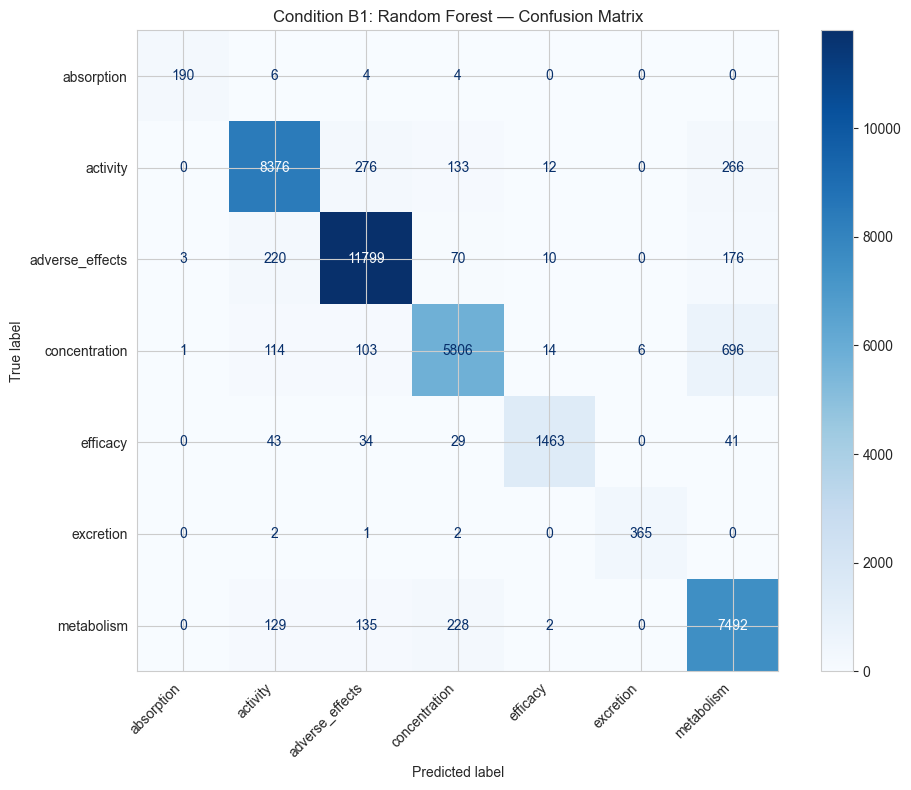

In [6]:
labels = sorted(set(y))

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Condition B1: Random Forest — Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


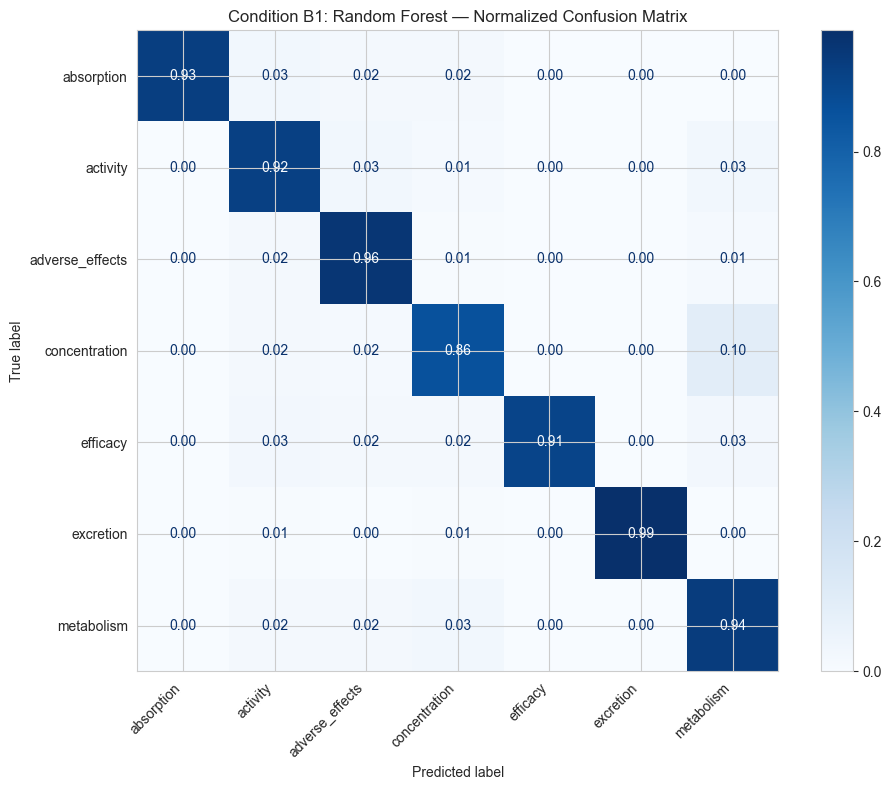

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='.2f')
ax.set_title('Condition B1: Random Forest — Normalized Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 3.3 Feature Importance

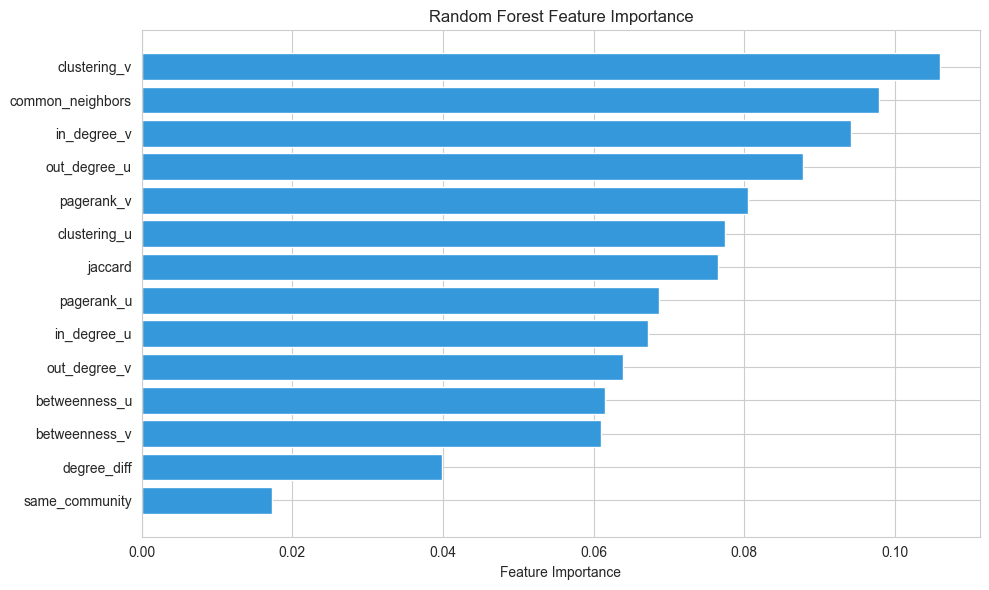

Feature importance ranking:
          clustering_v: 0.1060
      common_neighbors: 0.0979
           in_degree_v: 0.0942
          out_degree_u: 0.0878
            pagerank_v: 0.0806
          clustering_u: 0.0774
               jaccard: 0.0765
            pagerank_u: 0.0686
           in_degree_u: 0.0672
          out_degree_v: 0.0639
         betweenness_u: 0.0615
         betweenness_v: 0.0610
           degree_diff: 0.0399
        same_community: 0.0173


In [8]:
importances = clf.feature_importances_
feat_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='#3498db')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
for _, row in feat_imp.sort_values('importance', ascending=False).iterrows():
    print(f"  {row['feature']:>20s}: {row['importance']:.4f}")


## 4. Error Analysis

Where does the model make mistakes? Let's look at the most common confusion pairs.


In [9]:
# Find most confused pairs
errors = pd.DataFrame({
    'true': y_test,
    'pred': y_pred,
}).query('true != pred')

confusion_pairs = errors.groupby(['true', 'pred']).size().sort_values(ascending=False)
print(f"Total errors: {len(errors):,} / {len(y_test):,} ({len(errors)/len(y_test):.1%})")
print(f"\nTop 10 confusion pairs:")
print("-" * 50)
for (true_label, pred_label), count in confusion_pairs.head(10).items():
    print(f"  {true_label:>16s} → {pred_label:<16s}: {count:>4,}")


Total errors: 2,760 / 38,251 (7.2%)

Top 10 confusion pairs:
--------------------------------------------------
     concentration → metabolism      :  696
          activity → adverse_effects :  276
          activity → metabolism      :  266
        metabolism → concentration   :  228
   adverse_effects → activity        :  220
   adverse_effects → metabolism      :  176
        metabolism → adverse_effects :  135
          activity → concentration   :  133
        metabolism → activity        :  129
     concentration → activity        :  114


## 5. Save Results

In [10]:
# Save predictions for later comparison
results_b1 = pd.DataFrame({
    'true_label': y_test,
    'pred_label': y_pred,
})
results_b1.to_csv("../data/results_b1_rf.csv", index=False)
print(f"Saved results_b1_rf.csv: {len(results_b1):,} predictions")

# Store key metric
print(f"\n{'='*50}")
print(f"CONDITION B1 FINAL SCORE: Macro-F1 = {macro_f1:.4f}")
print(f"{'='*50}")


Saved results_b1_rf.csv: 38,251 predictions

CONDITION B1 FINAL SCORE: Macro-F1 = 0.9377


## Summary

**Condition B1 (Random Forest on graph features) results:**

| Metric | Score |
|--------|-------|
| **Macro-F1** | **0.9377** |
| Weighted-F1 | 0.9279 |
| Accuracy | 0.9278 |
| Random baseline (1/7) | 0.1429 |
| **Ratio over random** | **6.6x** |

**Key findings:**
- Graph topological features alone achieve 93.8% macro-F1 — extremely strong
- Top features: `clustering_v`, `common_neighbors`, `in_degree_v`, `out_degree_u`
- `same_community` is the least important feature (density of graph makes communities less distinctive)
- Main confusion: `metabolism` ↔ `concentration` (pharmacologically related mechanisms)
- Small classes (`absorption`, `excretion`) still classified well thanks to `class_weight='balanced'`

**This sets a high bar for conditions A (LLM-only) and C (LangGraph agent) to beat.**

**Next:** Phase 4 — Condition A (LLM-only baseline) in `04_llm_only.ipynb`
